In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import shutil
import pickle

In [2]:

ds_name = 'markov_32feat_11t5g_more_balanced_largeN_censor'
ds_df_dir = '/home/yc366/repos/survsurf_benchmark/dataset_split'
project = 'SurvSurfBenchmark_Markov_censored'
g_resol = 1
model_prefix = 'Joint'

DIR_MODEL_SAVE = os.path.join('sksurv_models', project, model_prefix)

if os.path.exists(DIR_MODEL_SAVE):
    shutil.rmtree(DIR_MODEL_SAVE)
    os.mkdir(DIR_MODEL_SAVE)
else:
    os.mkdir(DIR_MODEL_SAVE)

In [3]:
from dataset_11t5g_markov import DatasetMarkovSurvSurf

ds_train = DatasetMarkovSurvSurf(
    df_dir=ds_df_dir, 
    ds_name=ds_name, 
    g_resol=g_resol, 
    split='train', 
    mode='first_cross_obs_only', 
    separate_g_from_feats=False
)
ds_val = DatasetMarkovSurvSurf(
    df_dir=ds_df_dir, 
    ds_name=ds_name, 
    g_resol=g_resol, 
    split='val', 
    mode='first_cross_obs_only', 
    separate_g_from_feats=False
)


In [4]:
df_Xy_train = ds_train._get_df_Xy_trans_obs()

assert all(
    df_Xy_train.groupby(ds_train.colname_g)['subject'].apply(lambda x: x.value_counts().max() == 1)
)
df_Xy_train['event_observed'] = df_Xy_train['event_observed'].astype(bool)
df_Xy_train = df_Xy_train.sort_values('subject')

df_Xy_val = ds_val._get_df_Xy_trans_obs()
assert all(
    df_Xy_val.groupby(ds_train.colname_g)['subject'].apply(lambda x: x.value_counts().max() == 1)
)
df_Xy_val = df_Xy_val.sort_values('subject')
df_Xy_val['event_observed'] = df_Xy_val['event_observed'].astype(bool)

df_Xy_val_grid = ds_val._get_df_Xy_true_prob()
df_Xy_val_grid = df_Xy_val_grid.sort_values(['subject',ds_train.colname_g])

df_Xy_val_grid['event_observed'] = df_Xy_val_grid['event_observed'].astype(bool)


In [5]:
df_Xy_train.head()

,subject,event_observed,duration,g_max_by_time,feat00,feat01,feat02,feat03,feat04,feat05,...,feat24,feat25,feat26,feat27,feat28,feat29,feat30,feat31,weight,is_t_trans
0,0,False,8,1.0,0.883893,0.195865,0.357537,-2.343262,-1.084833,0.559696,...,-0.243339,-0.130031,-0.109017,1.556186,0.128778,-2.066949,-0.885493,0.0,1,1
1,4,True,4,3.0,-0.105813,2.009902,0.011231,-1.089429,-1.514511,-0.559761,...,-1.941266,0.341435,1.862855,-0.295230,0.478317,-0.715190,1.237293,1.0,1,1
2,4,True,8,4.0,-0.105813,2.009902,0.011231,-1.089429,-1.514511,-0.559761,...,-1.941266,0.341435,1.862855,-0.295230,0.478317,-0.715190,1.237293,1.0,1,1
3,4,False,10,5.0,-0.105813,2.009902,0.011231,-1.089429,-1.514511,-0.559761,...,-1.941266,0.341435,1.862855,-0.295230,0.478317,-0.715190,1.237293,1.0,1,1
4,8,True,2,1.0,-0.831544,-0.672747,0.670116,-1.148873,-0.267907,-0.951563,...,-0.164301,0.394063,-0.231680,-0.247626,-0.386632,0.022902,-0.712544,1.0,1,1


In [6]:
cols_y = ['event_observed', 'duration']
cols_X = np.r_[[ds_train.colname_g], df_Xy_train.columns[df_Xy_train.columns.str.startswith('feat')]]

In [7]:
cols_y

['event_observed', 'duration']

In [8]:
cols_X

array(['g_max_by_time', 'feat00', 'feat01', 'feat02', 'feat03', 'feat04',
       'feat05', 'feat06', 'feat07', 'feat08', 'feat09', 'feat10',
       'feat11', 'feat12', 'feat13', 'feat14', 'feat15', 'feat16',
       'feat17', 'feat18', 'feat19', 'feat20', 'feat21', 'feat22',
       'feat23', 'feat24', 'feat25', 'feat26', 'feat27', 'feat28',
       'feat29', 'feat30', 'feat31'], dtype=object)

In [9]:
from sksurv.ensemble import GradientBoostingSurvivalAnalysis, RandomSurvivalForest
from sksurv.linear_model import CoxnetSurvivalAnalysis, CoxPHSurvivalAnalysis
def get_non_cox_model(model_class):
    def get_model(n_jobs, random_state):
        try:
            return model_class(n_jobs=n_jobs, random_state=random_state, min_samples_leaf=3, n_estimators=1000)
        except TypeError:
            return model_class(random_state=random_state, min_samples_leaf=10, n_estimators=50)
    return get_model

def get_cox_model(model_class):
    def get_model(n_jobs, random_state):
        try:
            return model_class(fit_baseline_model=True, ties='efron')
        except TypeError:
            try:
                return model_class(fit_baseline_model=True)
            except TypeError:
                return model_class()
    return get_model

model_name_to_class = {
    f'{model_prefix}_{GradientBoostingSurvivalAnalysis.__name__}':get_non_cox_model(GradientBoostingSurvivalAnalysis),
    f'{model_prefix}_{RandomSurvivalForest.__name__}':get_non_cox_model(RandomSurvivalForest),
    f'{model_prefix}_{CoxnetSurvivalAnalysis.__name__}':get_cox_model(CoxnetSurvivalAnalysis),
    f'{model_prefix}_{CoxPHSurvivalAnalysis.__name__}':get_cox_model(CoxPHSurvivalAnalysis),
}

In [10]:
df_metrics = []
surv_funcs = dict()
event_to_model = dict()
seeds = [10,20,30,40,50]
for model_name, model_class in model_name_to_class.items():
    for seed in seeds:
        model_id = f'{model_name}_seed_{seed}'
        model = model_class(n_jobs=-1, random_state=seed)
        y = df_Xy_train[cols_y].to_records(index=False)
        X = df_Xy_train[cols_X]
        model.fit(X, y)

        model_path = os.path.join(DIR_MODEL_SAVE,f'{model_id}.pickle')
        with open(model_path, 'wb') as f:
            # Pickle the 'data' dictionary using the highest protocol available.
            pickle.dump(model, f)

        for g, df_train_sub in df_Xy_train.groupby(ds_train.colname_g):
            if all(df_train_sub['event_observed'] == 0):
                continue
            
            y = df_train_sub[cols_y].to_records(index=False)
            X = df_train_sub[cols_X]
            event_to_model[f'{model_id}_event_{g}'] = model
            record = {
                'model_name':model_name,
                'event':g,
                'seed':seed,
                'c_index_train':model.score(X,y)
            }

            df_val_sub = df_Xy_val.loc[
                df_Xy_val[ds_train.colname_g] == g,:
            ]
            y = df_val_sub[cols_y].to_records(index=False)
            X = df_val_sub[cols_X]
            record['c_index_val'] = model.score(X,y)
            df_metrics.append(record)

            df_val_sub = df_Xy_val_grid.loc[
                df_Xy_val_grid[ds_train.colname_g] == g,:
            ].drop(columns=['duration','event_observed']).drop_duplicates().sort_values('subject')
            X = df_val_sub[cols_X]

            surv_funcs[f'{model_id}_event_{g}'] = model.predict_survival_function(X=X)
        print(f'finished running model {model_name}')
df_metrics = pd.DataFrame(df_metrics)


finished running model Joint_GradientBoostingSurvivalAnalysis
finished running model Joint_GradientBoostingSurvivalAnalysis
finished running model Joint_GradientBoostingSurvivalAnalysis
finished running model Joint_GradientBoostingSurvivalAnalysis
finished running model Joint_GradientBoostingSurvivalAnalysis
finished running model Joint_RandomSurvivalForest
finished running model Joint_RandomSurvivalForest
finished running model Joint_RandomSurvivalForest
finished running model Joint_RandomSurvivalForest
finished running model Joint_RandomSurvivalForest
finished running model Joint_CoxnetSurvivalAnalysis
finished running model Joint_CoxnetSurvivalAnalysis
finished running model Joint_CoxnetSurvivalAnalysis
finished running model Joint_CoxnetSurvivalAnalysis
finished running model Joint_CoxnetSurvivalAnalysis
finished running model Joint_CoxPHSurvivalAnalysis
finished running model Joint_CoxPHSurvivalAnalysis
finished running model Joint_CoxPHSurvivalAnalysis
finished running model Join

In [11]:
df_val_sub

,subject,g_max_by_time,feat00,feat01,feat02,feat03,feat04,feat05,feat06,feat07,...,feat24,feat25,feat26,feat27,feat28,feat29,feat30,feat31,weight,is_t_trans
4,6,5,0.805669,-0.012551,-0.260823,-0.889478,-1.615899,-0.851965,-0.041180,-0.270327,...,-0.708124,1.414139,-0.490533,1.181171,-0.046925,-1.460106,-0.508191,0.0,1,NaN
9,15,5,1.905088,0.952670,-0.432973,-0.730569,-1.093725,0.437599,-0.761883,-1.029683,...,-1.071806,1.491680,-0.412008,1.125530,0.298597,0.380416,-0.360827,0.0,1,NaN
14,17,5,-0.851021,0.382710,-2.104251,0.611296,0.334314,1.881421,-0.924426,-0.457373,...,0.820551,0.305156,-1.235898,0.832217,0.382172,-0.732978,0.506060,0.0,1,NaN
19,18,5,0.704272,-0.820974,-0.175555,1.109713,0.091841,-0.194910,-0.365020,-0.301989,...,2.344199,0.458714,-2.766334,0.205854,1.171364,-1.175700,-0.128304,0.0,1,NaN
24,19,5,0.287647,1.635691,0.114950,0.176676,-0.271338,-0.748332,-0.812047,0.759777,...,0.149182,-0.036294,0.197549,0.526756,-1.869619,0.469936,-0.386902,1.0,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2479,3955,5,0.196634,-0.156305,0.665766,-0.268307,-0.574615,0.774962,-0.906287,-1.639456,...,-1.498315,-1.230395,0.858906,0.020648,0.767775,-1.268084,0.233195,1.0,1,NaN
2484,3975,5,-0.633409,0.625880,-0.850300,-0.133533,-0.055059,-1.042822,-0.523275,1.238877,...,0.582240,0.372278,1.227529,-0.708982,0.269353,0.808051,-0.260780,0.0,1,NaN
2489,3985,5,-0.060744,-0.420708,0.271252,-1.644419,0.121250,-0.988747,3.145469,-0.945511,...,-0.284836,-1.144053,1.222501,-0.280542,-0.240934,1.715149,-0.347427,1.0,1,NaN
2494,3986,5,-1.787554,-0.954522,-1.066753,-0.589795,-0.318407,0.886084,-1.268265,-1.497707,...,2.417236,-0.473942,0.424058,1.677425,1.109402,1.301498,-0.207486,1.0,1,NaN


In [12]:
df_metrics.groupby(['model_name','event'])['c_index_val'].describe()

count      mean       std  \
model_name                             event                              
Joint_CoxPHSurvivalAnalysis            1.0      5.0  0.698443  0.000000   
                                       2.0      5.0  0.733199  0.000000   
                                       3.0      5.0  0.521857  0.000000   
                                       4.0      5.0  0.501921  0.000000   
                                       5.0      5.0  0.478405  0.000000   
Joint_CoxnetSurvivalAnalysis           1.0      5.0  0.500000  0.000000   
                                       2.0      5.0  0.500000  0.000000   
                                       3.0      5.0  0.500000  0.000000   
                                       4.0      5.0  0.500000  0.000000   
                                       5.0      5.0  0.500000  0.000000   
Joint_GradientBoostingSurvivalAnalysis 1.0      5.0  0.640981  0.000000   
                                       2.0      5.0  0.721335  0.000000   
                                       3.0      5.0  0.566920  0.000000   
                                       4.0      5.0  0.495198  0.000000   
                                       5.0      5.0  0.524917  0.000000   
Joint_RandomSurvivalForest             1.0      5.0  0.712443  0.003783   
                                       2.0      5.0  0.743927  0.004072   
                                       3.0      5.0  0.583190  0.003402   
                                       4.0      5.0  0.500128  0.015461   
                                       5.0      5.0  0.518272  0.034285   

                                                   min       25%       50%  \
model_name                             event                                 
Joint_CoxPHSurvivalAnalysis            1.0    0.698443  0.698443  0.698443   
                                       2.0    0.733199  0.733199  0.733199   
                                       3.0    0.521857  0.521857  0.521857   
                                       4.0    0.501921  0.501921  0.501921   
                                       5.0    0.478405  0.478405  0.478405   
Joint_CoxnetSurvivalAnalysis           1.0    0.500000  0.500000  0.500000   
                                       2.0    0.500000  0.500000  0.500000   
                                       3.0    0.500000  0.500000  0.500000   
                                       4.0    0.500000  0.500000  0.500000   
                                       5.0    0.500000  0.500000  0.500000   
Joint_GradientBoostingSurvivalAnalysis 1.0    0.640981  0.640981  0.640981   
                                       2.0    0.721335  0.721335  0.721335   
                                       3.0    0.566920  0.566920  0.566920   
                                       4.0    0.495198  0.495198  0.495198   
                                       5.0    0.524917  0.524917  0.524917   
Joint_RandomSurvivalForest             1.0    0.708309  0.708636  0.713362   
                                       2.0    0.737993  0.742546  0.744128   
                                       3.0    0.579072  0.581603  0.583460   
                                       4.0    0.486556  0.486556  0.494238   
                                       5.0    0.465116  0.514950  0.518272   

                                                   75%       max  
model_name                             event                      
Joint_CoxPHSurvivalAnalysis            1.0    0.698443  0.698443  
                                       2.0    0.733199  0.733199  
                                       3.0    0.521857  0.521857  
                                       4.0    0.501921  0.501921  
                                       5.0    0.478405  0.478405  
Joint_CoxnetSurvivalAnalysis           1.0    0.500000  0.500000  
                                       2.0    0.500000  0.500000  
                                       3.0    0.500000  0.500000  
        

In [13]:
df = df_metrics.copy()
df['val_as_frac_of_train'] = df_metrics['c_index_val']/df_metrics['c_index_train']
df.groupby(['model_name','event'])['val_as_frac_of_train'].describe()

count      mean           std  \
model_name                             event                                  
Joint_CoxPHSurvivalAnalysis            1.0      5.0  0.954256  0.000000e+00   
                                       2.0      5.0  1.068658  0.000000e+00   
                                       3.0      5.0  0.956095  0.000000e+00   
                                       4.0      5.0  0.841339  0.000000e+00   
                                       5.0      5.0  0.838329  0.000000e+00   
Joint_CoxnetSurvivalAnalysis           1.0      5.0  1.000000  0.000000e+00   
                                       2.0      5.0  1.000000  0.000000e+00   
                                       3.0      5.0  1.000000  0.000000e+00   
                                       4.0      5.0  1.000000  0.000000e+00   
                                       5.0      5.0  1.000000  0.000000e+00   
Joint_GradientBoostingSurvivalAnalysis 1.0      5.0  0.809217  0.000000e+00   
                                       2.0      5.0  0.939924  1.241267e-16   
                                       3.0      5.0  0.786729  0.000000e+00   
                                       4.0      5.0  0.793215  0.000000e+00   
                                       5.0      5.0  0.800299  0.000000e+00   
Joint_RandomSurvivalForest             1.0      5.0  0.804198  4.281429e-03   
                                       2.0      5.0  0.780008  4.430198e-03   
                                       3.0      5.0  0.613445  3.758722e-03   
                                       4.0      5.0  0.583370  1.882651e-02   
                                       5.0      5.0  0.584243  4.033114e-02   

                                                   min       25%       50%  \
model_name                             event                                 
Joint_CoxPHSurvivalAnalysis            1.0    0.954256  0.954256  0.954256   
                                       2.0    1.068658  1.068658  1.068658   
                                       3.0    0.956095  0.956095  0.956095   
                                       4.0    0.841339  0.841339  0.841339   
                                       5.0    0.838329  0.838329  0.838329   
Joint_CoxnetSurvivalAnalysis           1.0    1.000000  1.000000  1.000000   
                                       2.0    1.000000  1.000000  1.000000   
                                       3.0    1.000000  1.000000  1.000000   
                                       4.0    1.000000  1.000000  1.000000   
                                       5.0    1.000000  1.000000  1.000000   
Joint_GradientBoostingSurvivalAnalysis 1.0    0.809217  0.809217  0.809217   
                                       2.0    0.939924  0.939924  0.939924   
                                       3.0    0.786729  0.786729  0.786729   
                                       4.0    0.793215  0.793215  0.793215   
                                       5.0    0.800299  0.800299  0.800299   
Joint_RandomSurvivalForest             1.0    0.798475  0.801448  0.804889   
                                       2.0    0.773834  0.777578  0.781077   
                                       3.0    0.610429  0.610503  0.613223   
                                       4.0    0.566595  0.569166  0.573491   
                                       5.0    0.522463  0.578757  0.585045   

                                                   75%       max  
model_name                             event                      
Joint_CoxPHSurvivalAnalysis            1.0    0.954256  0.954256  
                                       2.0    1.068658  1.068658  
                                       3.0    0.956095  0.956095  
                                       4.0    0.841339  0.841339  
                                       5.0    0.838329  0.838329  
Joint_CoxnetSurvivalAnalysis           1.0    1.000000  1.000000  
                                       2.0    1.000000

([0, 1, 2, 3],
 [Text(0, 0, 'Joint_GradientBoostingSurvivalAnalysis'),
  Text(1, 0, 'Joint_RandomSurvivalForest'),
  Text(2, 0, 'Joint_CoxnetSurvivalAnalysis'),
  Text(3, 0, 'Joint_CoxPHSurvivalAnalysis')])

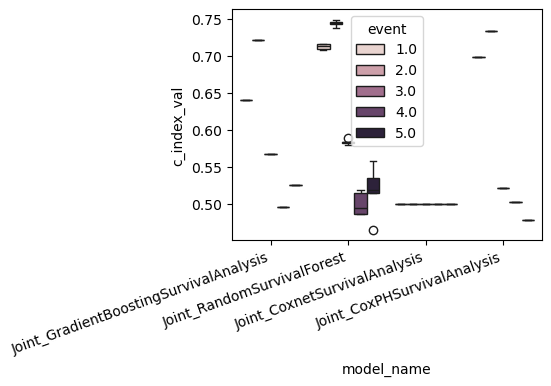

In [14]:
fig, ax = plt.subplots(1,1, figsize=(4, 3))
sns.boxplot(
    data=df_metrics,
    x='model_name',
    y='c_index_val',
    hue='event',
    ax=ax,
)
plt.xticks(rotation=20, ha='right')


In [15]:
n_curves_per_model = [len(i) for i in surv_funcs.values()]

n_curves_per_model = n_curves_per_model[0]

In [16]:
list(surv_funcs.keys())

['Joint_GradientBoostingSurvivalAnalysis_seed_10_event_1.0',
 'Joint_GradientBoostingSurvivalAnalysis_seed_10_event_2.0',
 'Joint_GradientBoostingSurvivalAnalysis_seed_10_event_3.0',
 'Joint_GradientBoostingSurvivalAnalysis_seed_10_event_4.0',
 'Joint_GradientBoostingSurvivalAnalysis_seed_10_event_5.0',
 'Joint_GradientBoostingSurvivalAnalysis_seed_20_event_1.0',
 'Joint_GradientBoostingSurvivalAnalysis_seed_20_event_2.0',
 'Joint_GradientBoostingSurvivalAnalysis_seed_20_event_3.0',
 'Joint_GradientBoostingSurvivalAnalysis_seed_20_event_4.0',
 'Joint_GradientBoostingSurvivalAnalysis_seed_20_event_5.0',
 'Joint_GradientBoostingSurvivalAnalysis_seed_30_event_1.0',
 'Joint_GradientBoostingSurvivalAnalysis_seed_30_event_2.0',
 'Joint_GradientBoostingSurvivalAnalysis_seed_30_event_3.0',
 'Joint_GradientBoostingSurvivalAnalysis_seed_30_event_4.0',
 'Joint_GradientBoostingSurvivalAnalysis_seed_30_event_5.0',
 'Joint_GradientBoostingSurvivalAnalysis_seed_40_event_1.0',
 'Joint_GradientBoosting